In [7]:
import sys
sys.path.append('..')
from utils.filters import *
from utils.baseline_tools import *
import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
from utils.display_tools import load_best_forecasts, display_predictions, display_predictions_2
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.general_tools import pd_to_param_holder
import functools as ft

import matplotlib.pyplot as plt
from utils.general_tools import results_to_pd
from utils.modeling_tools import perform_modeling_sarimax, perform_modeling_varmax
from statsmodels.datasets import sunspots
from statsmodels.tsa.deterministic import Fourier

In [2]:
%load_ext autoreload
%autoreload 2

## Display the forecasts and save them properly into a table

In [3]:
data = pickle.load(open("../saves_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [4]:
display = exogs["Lister"]

In [5]:
display.index = display["datetime"]

In [8]:
fourier_gen = Fourier(365, order=1)
four = fourier_gen.in_sample(display.loc[display.index.year >2014, "W"].index)

Text(0.5, 1.0, 'Fourier Terms (Annual Cycle)')

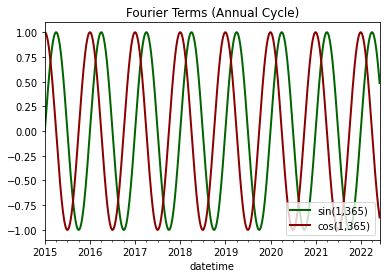

In [9]:
four.plot(linewidth=2, color = ["darkgreen", "darkred"])
plt.legend(loc=4)
plt.title("Fourier Terms (Annual Cycle)")

Text(0.5, 1.0, 'Water level')

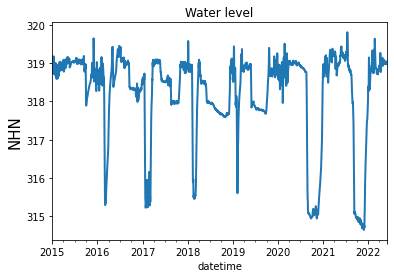

In [10]:
display.loc[display.index.year >2014, "W"].plot(linewidth=2)#, linestyle="dotted")))
plt.ylabel("NHN", fontsize=15)
plt.title("Water level")

Text(0.5, 1.0, 'Air temperature at 2m height')

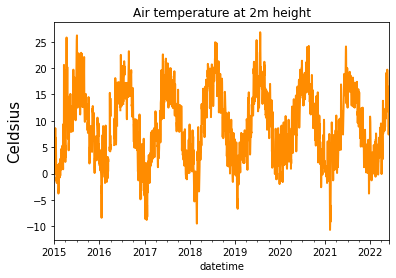

In [11]:
display.loc[display.index.year >2014, "T"].plot(color="darkorange", linewidth=2)
plt.ylabel("Celdsius", fontsize=15)
plt.title("Air temperature at 2m height")

In [12]:
data["Lister"]["asc0"]= data["Lister"]["asc0"].interpolate().reset_index()

In [13]:
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)[0:]

Text(0, 0.5, 'deformation in mm')

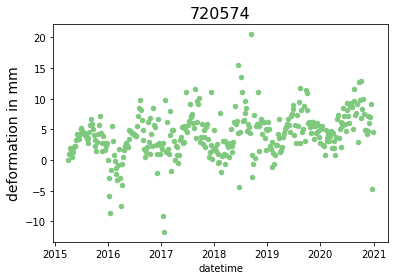

In [14]:
data["Lister"]["asc0"].plot.scatter(x="datetime", y= "720574", color = colors[0])
plt.title("720574", fontsize=16)
plt.ylabel("deformation in mm", fontsize=14)

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


Text(0, 0.5, '')

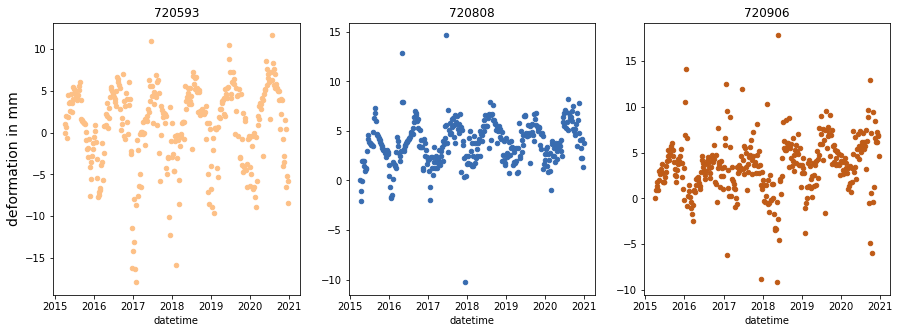

In [15]:
fix, axs = plt.subplots(1,3, figsize=(15,5))


for n,x in enumerate(["720593","720808","720906"]):
    data["Lister"]["asc0"].plot.scatter(x="datetime", y= x , c = colors[n+1], ax= axs[n])
    axs[n].set_title(x)
axs[0].set_ylabel("deformation in mm", fontsize=14)
axs[1].set_ylabel("", fontsize=14)
axs[2].set_ylabel("", fontsize=14)

In [ ]:
loc = "Lister"
direction = "asc0"
row_length = 2

In [22]:
d

,datetime,720574,720593,720808,720906
0,2015-04-04,0.000000,0.000000,0.000000,0.000000
1,2015-04-10,0.982570,1.005795,-1.049175,0.900050
2,2015-04-16,1.965140,2.011590,-2.098350,1.800100
3,2015-04-22,1.276725,0.655115,-0.048480,1.356507
4,2015-04-28,0.588311,-0.701360,2.001390,0.912913
...,...,...,...,...,...
345,2020-12-03,6.059630,-6.488100,2.287860,6.108040
346,2020-12-09,6.980410,0.444366,2.287280,7.296000
347,2020-12-15,9.091390,-5.184450,4.210810,6.790360
348,2020-12-21,-4.758610,-5.842330,1.333730,6.918940


In [23]:
d = data[loc][direction]
d.set_index("datetime", inplace=True)
y_ = d.loc[d.index.year == 2020]

In [24]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts("results/igarss/fc_igarss", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score

# Performance visualization

/tmp/ipykernel_3761520/4286373824.py:1: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 2)[0]


Position = 200.0
Position = 200.0
Position = 200.0
Position = 200.0


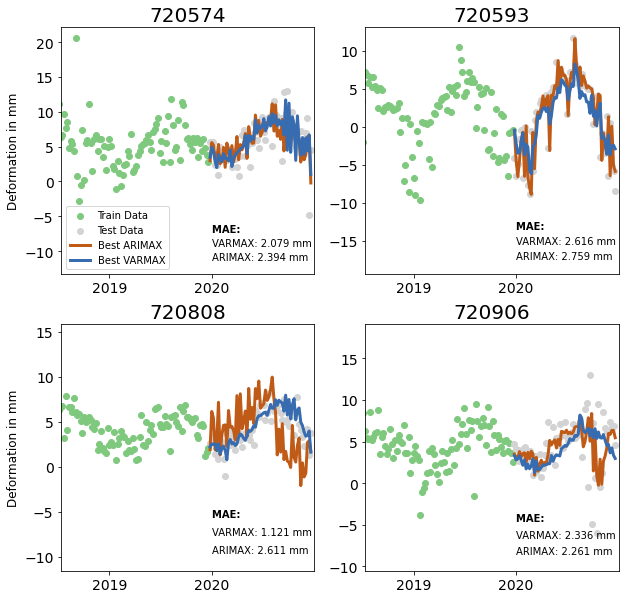

In [25]:
tickPos = np.where(d.index.weekofyear == 2)[0]
tickPos = [x for x in tickPos if x - 1 not in tickPos]
tickLabels = np.arange(2016, 2021)

cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)

rows = int(len(d.columns)/ row_length)
fig, axs = plt.subplots(rows, row_length, figsize=(5 * row_length, 5 * rows))
axs = axs.reshape(-1)
for n, key in enumerate(d.columns):
    train = d.loc[d.index.year < 2020, key].interpolate()
    test = d.loc[d.index.year >= 2020, key].interpolate()

    axs[n].scatter(np.arange(len(train)), train.values, label="Train Data", color = colors[0])
    axs[n].scatter(np.arange(len(train), len(train)+ len(test)), test, label="Test Data", color="lightgrey")

    axs[n].set_title(key, fontsize=20)
    axs[n].tick_params(
        axis="both", which="major", labelsize=14
    )

    axs[n].set_xticks(
        ticks=tickPos, labels=tickLabels, fontsize=14
    )
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], fc["sarimax"][key][:61], color = colors[3],alpha=1, linewidth=3, label="Best ARIMAX")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], sa_n[key], color="black", linewidth=3, label="Sarimax new")
    axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], fc["var"][key][:61], color = colors[2], linewidth=3, label="Best VARMAX")
    #axs[n].plot(np.arange(len(train), len(train) + len(test))[:61], f_n[key], color="darkblue", linewidth=3, label="Random forest")
    axs[n].set_xlim([200,351])
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+6,"MAE: " , weight='bold')
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+4,"VARMAX: " + str(round(mae["var"].loc[key].values[0],3)) + " mm")
    axs[n].text(axs[n].get_xlim()[0]+90,axs[n].get_ylim()[0]+2,"ARIMAX: " + str(round(mae["sarimax"].loc[key].values[0],3)) + " mm")
    print("Position =" , axs[n].get_xlim()[0])
axs[0].legend()


axs[0].set_ylabel("Deformation in mm", fontsize=12)
axs[2].set_ylabel("Deformation in mm", fontsize=12)

#fig.suptitle('Forecast for 2020 at the Lister', fontsize=20)

fig.savefig("img_1", dpi=300)

## Rerun

In [26]:
# some ugly refractor because of loading:
for key in ["sarimax","var"]: #  "var"
    for y in ["T", "STAU"]:
        stack = []
        for x in ms[key]["Index"]:
            split = ms[key].loc[ms[key]["Index"] == x, y].values[0][1:-1]
            if len (split) != 0:
                stack.append(
                    np.array(
                        split.split(" ")).astype(int)
                )
            else:
                stack.append(np.array([]))

        ms[key][y] = stack

/tmp/ipykernel_3761520/3370888832.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms[key][y] = stack


In [27]:
# Runs quite a bit.
fc_stack = {}
model_stack = []
for model_type in ["sarimax", "var"]: # var
    print(model_type)
    preds = []
    for ind in ms[model_type]["Index"]:
        combo = pd_to_param_holder(ms[model_type], ind)
        (train,
        test,
        max_data,
        min_data,
        trend,
        seasonality,
        test_trend,
        test_seasonality) = (
        full_preprocessing_pipeline(data[loc][direction], exogs[loc], combo, model_search=False)
        )
        #
        #test[1] = test[1].clip(lower=0,upper=1)
        
        if model_type == "sarimax":
            model = perform_modeling_sarimax(train[0][str(ind)], train[1], combo)

            if len(test[1].columns) != 0:
                append_model = model.append(test[0][str(ind)], refit=False, exog=test[1])
            else:
                append_model = model.append(test[0][str(ind)], refit=False)

            pred_one_step = append_model.predict(start=test[0].index[0])
            pred_one_step = pd.DataFrame(pred_one_step)
            pred_one_step.columns = [str(ind)]
            model_stack.append(append_model)
            
        else:
            model = perform_modeling_varmax(train[0], train[1], combo)
            if len(test[1].columns) != 0:
                append_res = model.append(test[0], refit=False, exog=test[1])
            else:
                append_res = model.append(test[0], refit=False)
            pred = append_res.predict(start=test[0].index[0])
            pred.columns = test[0].columns
            pred = pd.DataFrame(pred[str(ind)])
            pred.columns = [str(ind)]
            pred_one_step = pred

        # Transform to original range and appends results
        Y, Y_hat = bring_to_original_range(
            test[0][str(ind)],
            pred_one_step[str(ind)],
            max_data[str(ind)],
            min_data[str(ind)],
            (test_trend[str(ind)] if isinstance(trend, pd.DataFrame) else None),
            (test_seasonality[str(ind)] if isinstance(seasonality, pd.DataFrame) else None),
            data[loc][direction],
            str(ind),
        )
        preds.append(Y_hat)
    preds = pd.concat(preds, axis=1)
    #preds.columns = ms[model_type]["Index"].values
    fc_stack[model_type] = preds

sarimax


ValueError: 'datetime' is both an index level and a column label, which is ambiguous.

## Baseline performance

In [28]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts("results/fc_igarss_baseline", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score
mae

FileNotFoundError: [Errno 2] No such file or directory: 'results/fc_igarss_baseline'

In [250]:
ms = {}
fc = {}
mae = {}


model_spec, forecasts = load_best_forecasts("results/fc_igarss", direction=direction)


for key in forecasts:
    score = pd.DataFrame(
        (np.abs(forecasts[key] - y_.values).mean().values),
        index=forecasts[key].columns,
        columns=["MAE"],
    )
    ms[key] = model_spec.loc[model_spec.index == key]
    fc[key] = forecasts[key]
    mae[key] = score
mae

{'var':              MAE
 720574  2.111268
 720593  2.677257
 720808  1.147231
 720906  2.329522,
 'sarimax':              MAE
 720574  2.428219
 720593  2.865795
 720808  2.509723
 720906  2.297597}

In [253]:




out_stack = []
for x in ["asc0", "desc0", "ew", "ver"]:
    mae = {}
    d = data[loc][x]
    y_ = d.loc[d.index.year == 2020]
    model_spec, forecasts = load_best_forecasts("results/fc_igarss_baseline", direction=x)
    

    for key in forecasts:
        score = pd.DataFrame(
            (np.abs(forecasts[key] - y_.values).mean().values),
            index=forecasts[key].columns,
            columns=["MAE"],
        )
        mae[key] = score

        out_stack.append(mae["sarimax"].mean())
pd.concat(out_stack,axis=1),pd.concat(out_stack,axis=1).mean(axis=1)

(            0         1         2         3
 MAE  4.102477  4.208289  4.103649  2.918006,
 MAE    3.833105
 dtype: float64)

In [231]:
out_stack = []
for x in ["asc0", "desc0", "ew", "ver"]:
    mae = {}
    d = data[loc][x]
    y_ = d.loc[d.index.year == 2020]
    model_spec, forecasts = load_best_forecasts("results/fc_igarss", direction=x)
    

    for key in forecasts:
        score = pd.DataFrame(
            (np.abs(forecasts[key] - y_.values).mean().values),
            index=forecasts[key].columns,
            columns=["MAE"],
        )
        mae[key] = score
    out_stack.append(mae)

In [239]:
pd.concat([x["var"].mean() for x in out_stack], axis=1),pd.concat([x["var"].mean() for x in out_stack], axis=1).mean(axis=1)

(           0         1         2         3
 MAE  2.06632  1.855622  1.795191  1.508346,
 MAE    1.80637
 dtype: float64)

In [240]:
pd.concat([x["sarimax"].mean() for x in out_stack], axis=1),pd.concat([x["sarimax"].mean() for x in out_stack], axis=1).mean(axis=1)

(            0         1         2         3
 MAE  2.525334  2.318257  2.019027  1.725855,
 MAE    2.147118
 dtype: float64)

# Training performance distribution ( Not used)

In [13]:
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Set2(x) for x in cm_subsection])
colors = list(colors)

In [14]:
origin = "results/igarss_new"

sar_grid = pickle.load(open(origin + "/" + loc + "_" + "asc0" + "_sarimax_results_stack.p", "rb"))            
var_grid = pickle.load(open(origin + "/" + loc + "_" + "asc0" + "_var_results_stack.p", "rb"))            
                
sar_grid  = results_to_pd(sar_grid)
var_grid  = results_to_pd(var_grid)

3888
1944


4


/tmp/ipykernel_1340925/3753723874.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)


4
4
4


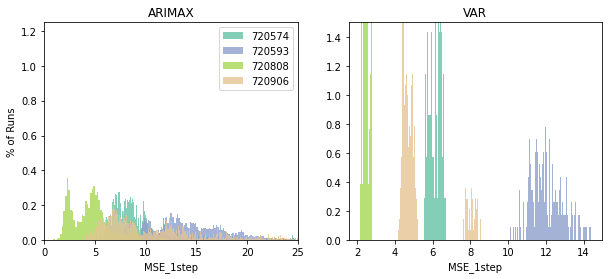

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
axs = axs.reshape(-1)

origin = "testing"

for n,p in enumerate(sar_grid["Index"].unique()):
    print(len(sar_grid["Index"].unique()))
    axs[0].hist(sar_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)
    axs[1].hist(var_grid[sar_grid.Index == p]["MSE_1step"], bins=640, density= True,alpha=0.8, color= colors[n], label = p)
axs[0].set_xlabel("MSE_1step")
axs[1].set_xlabel("MSE_1step")

axs[0].set_ylabel("% of Runs")
axs[0].set_xlim([0,25])
axs[0].set_ylim([0,1.25])
axs[1].set_ylim([0,1.5])

axs[0].set_title("ARIMAX")
axs[1].set_title("VAR")

axs[0].legend()

#fig.suptitle("Performance Distribution of the model search space")

# Residual distributios

In [29]:
cm_subsection = linspace(0,1,5)
colors = iter([ cm.Accent(x) for x in cm_subsection])
colors = list(colors)

KeyError: 'sarimax'

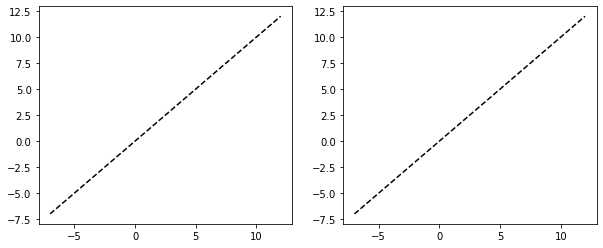

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
axs = axs.reshape(-1)

axs[0].plot(np.arange(-7,13),np.arange(-7,13), color = "black", linestyle = "dashed")
axs[1].plot(np.arange(-7,13),np.arange(-7,13), color = "black", linestyle = "dashed")

for n,x in enumerate(y_.columns):
    axs[0].scatter(y_[x].values,fc["sarimax"][x].values, label=x, color = colors[n], alpha=0.8 )
    axs[1].scatter(y_[x].values,fc["var"][x].values, label=x, color = colors[n], alpha=0.8 )

    axs[0].set_xlabel("True values ")
    axs[0].set_ylabel("Predicted values ")

    axs[1].set_xlabel("True values ")
    axs[1].set_ylabel("Predicted values")

axs[0].legend()
axs[0].set_title("ARIMAX Residuals")
axs[1].set_title("VARMAX Residuals")

#fig.suptitle('Residual distribution for Lister in ascending direction', fontsize=12)

fig.savefig("image_2.png", dpi=300)

# Parameter strength 

In [179]:
params = pickle.load(open("results/fc_igarss/Lister_asc0_sarimax_model_stack.p", "rb"))
paramsV = pickle.load(open("results/fc_igarss/Lister_asc0_var_model_stack.p", "rb"))

In [180]:
extract = [pd.DataFrame([ x[:2] for x in ((table.summary()).tables[1]).data[1:]]) for table in params]
extractV = [pd.DataFrame([ x[:2] for x in ((table.summary()).tables[2]).data[1:]]) for table in paramsV]

In [181]:
df_final = ft.reduce(lambda left, right: pd.merge(left, right, on=0, how="outer"), extract)
df_finalV = ft.reduce(lambda left, right: pd.merge(left, right, on=0, how="outer"), extractV)

In [182]:
df_final

,0,1_x,1_y,1_x,1_y
0,intercept,0.0631,0.0008,-0.0176,-0.0002
1,drift,4.617e-07,-5.825e-06,0.0004,-8.277e-07
2,sin_order_1,0.0148,NaN,-0.1376,-0.0023
3,cos_order_1,0.0416,NaN,0.0263,-0.0038
4,W_mean_3_0,0.9520,NaN,0.3057,1.3952
5,W_0,0.1764,NaN,NaN,-0.1769
6,W_1,-1.0714,NaN,NaN,-0.3863
7,T_0,0.3179,-0.0874,0.6615,NaN
8,ar.L1,0.6754,NaN,NaN,-0.4362
9,ar.L2,0.0676,NaN,NaN,-0.2753


In [187]:
pd.concat(
    [
        df_finalV[df_finalV[0].isin([x for x in df_finalV[0] if "T" in x])],
        df_finalV[df_finalV[0].isin([x for x in df_finalV[0] if "W" in x])],
    ]
)

,0,1_x,1_y,1_x,1_y
26,beta.T_mean_7_0,-0.0537,NaN,NaN,0.0392
28,beta.T_0,0.1461,NaN,0.1149,NaN
39,beta.T_mean_3_0,NaN,NaN,-0.3214,NaN
40,beta.T_1,NaN,NaN,0.0695,NaN
41,beta.T_2,NaN,NaN,0.2594,NaN
27,beta.W_0,0.0003,-0.1073,-0.1469,0.0300
29,beta.W_1,NaN,0.1197,0.2396,NaN
38,beta.W_mean_7_0,NaN,NaN,-0.0869,-0.0237


In [186]:
pd.concat(
    [
        df_final[df_final[0].isin([x for x in df_final[0] if "T" in x])],
        df_final[df_final[0].isin([x for x in df_final[0] if "W" in x])],
    ]
)

,0,1_x,1_y,1_x,1_y
7,T_0,0.3179,-0.0874,0.6615,NaN
14,T_mean_3_0,NaN,0.0476,NaN,0.0363
4,W_mean_3_0,0.9520,NaN,0.3057,1.3952
5,W_0,0.1764,NaN,NaN,-0.1769
6,W_1,-1.0714,NaN,NaN,-0.3863
13,W_mean_7_0,NaN,-0.0158,NaN,NaN
15,W_2,NaN,NaN,NaN,-0.8671


In [178]:
pd.DataFrame(np.array([var_grid[var_grid.Index == x].sort_values("MSE")[:1].values[0] for x in var_grid.Index.unique()]), columns=var_grid.columns)

,Index,MSE,MAE,MSE_1step,MAE_1step,AIC,MAPE,MAPE_1step,P,D,...,STAU,T,M_Stau,M_T,Decompose,Interaction,Estimator,n_estimator,max_depth,learning_rate
0,720574,5.093458,-0.514565,5.554781,-0.616483,0.358716,0.382873,-1636.384042,0,None,...,[0],[0],3,0,1,0,None,None,None,None
1,720593,9.517886,-0.80372,10.403337,-1.452375,2.477206,2.479954,-1694.784499,2,None,...,"[0, 1]","[0, 1]",0,3,1,0,None,None,None,None
2,720808,1.531838,-0.01997,2.260407,-0.182268,0.305555,0.39111,-1963.856942,2,None,...,"[0, 1]",[0],0,0,0,0,None,None,None,None
3,720906,4.216344,0.76172,4.258746,0.763686,0.349495,0.347961,-1628.408297,0,None,...,[0],[0],0,3,1,0,None,None,None,None
